In [84]:
import geopandas as gpd
import pandas as pd
import numpy as np
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [85]:
total = gpd.read_file('preliminary-map')

In [86]:
codigos_miro = [
    "AMB-003-A",
    "AMB-005-A",
    "AMB-006-A",
    "AMB-007-AT",
    "AMB-008-AT",
    "AMB-012-A",
    "AMB-017-A",
    "AMB-019-A",
    "AMB-020-A",
    "AMB-021-A",
    # "AMB-028-AT",
    "AMB-029-AT",
    "AMB-030-AT",
    "AMB-031-A",
    "AMB-033-A",
    "AMB-034-A",
    "AMB-036-A",
    "AMB-038-A",
    # "TEC-016-A",
    "AMB-040-A"
]
len(codigos_miro)

18

In [87]:
df_scores = pd.read_csv('intervalos.csv', sep = ',',index_col=0)
df_scores

,0,1,2,3,4,5
codigo,,,,,,
AMB-006-A,areas humedas continentales;areas humedas cost...,bosques,cultivos permanentes;zonas verdes artificializ...,cultivos transitorios;areas agricolas heteroge...,areas con vegetacion herbacea y/o arbustiva,"areas abiertas, sin o con poca vegetacion;pastos"
AMB-007-AT,30;60,24;30,18;24,12;18,6;12,0;6
AMB-030-AT,-6000;-100,-80;-100,-60;-80,-40;-60,-20;-40,-20;0
AMB-040-A,NaN,ALTA,MEDIA,NaN,BAJA,NaN
AMB-008-AT,5732;2000,1500;2000,1000;1500,500;1000,200;500,0;200
AMB-029-AT,Roca Sedimentaria;No clasificada,NaN,NaN,NaN,Roca dura,NaN


In [88]:
from geo_score_converter import GeoIntervalScorer

converter = GeoIntervalScorer()
total_scored = converter.transform(total)
total_scored.head()

,h3,AMB-003-A,AMB-005-A,AMB-006-A,AMB-007-AT,AMB-008-AT,AMB-012-A,AMB-017-A,AMB-019-A,AMB-020-A,AMB-021-A,AMB-029-AT,AMB-030-AT,AMB-031-A,AMB-033-A,AMB-034-A,AMB-036-A,AMB-038-A,AMB-041-A,geometry
0,88e74ab153fffff,5,5,4,5.0,5.0,0.0,5,0,0,0,NaN,5.0,0,0,0,0,0,NaN,"POLYGON ((5325672.764 2270751.835, 5326192.707..."
1,88e74e391bfffff,0,0,NaN,5.0,5.0,0.0,0,0,0,0,NaN,5.0,0,0,0,0,0,NaN,"POLYGON ((5277632.122 2453118.543, 5278155.352..."
2,88ef9e3307fffff,5,0,0,5.0,4.0,0.0,0,0,0,0,NaN,5.0,0,0,0,0,0,NaN,"POLYGON ((4714660.425 1703928.869, 4715184.234..."
3,88e75c583bfffff,0,0,NaN,NaN,NaN,0.0,0,0,0,0,NaN,0.0,0,0,0,0,0,NaN,"POLYGON ((5400394.434 3191045.991, 5400910.973..."
4,88f1693865fffff,0,0,NaN,NaN,NaN,0.0,0,0,0,0,NaN,0.0,0,0,0,0,0,NaN,"POLYGON ((3845240.623 1229251.959, 3845730.612..."


In [89]:
from pesos_variables import pesos_dict

pesos = pesos_dict()
cols = [c for c in total_scored.columns if c in pesos]
pesos_df = pd.DataFrame({"Codigo": cols, "Peso": [pesos[c] for c in cols]})

df_tipos = pd.read_csv('codigo_tipos(in).csv', sep=';')

[np.float64(0.26180759542031573), np.float64(0.26180759542031573), np.float64(0.11253474328785555), np.float64(0.1678615316233953), np.float64(0.07858778306208355), np.float64(0.05870037559301703), np.float64(0.05870037559301703)]
[['AMB-003-A'], ['AMB-005-A'], ['AMB-017-A'], ['AMB-019-A'], ['AMB-020-A'], ['AMB-034-A'], ['AMB-038-A']]
[np.float64(0.25642857142857145), np.float64(0.12821428571428573), np.float64(0.47714285714285715), np.float64(0.1382142857142857)]
[['AMB-012-A'], ['AMB-033-A'], ['AMB-021-A'], ['AMB-036-A']]
[np.float64(0.6000000000000001), np.float64(0.4)]
[['AMB-031-A'], ['AMB-041-A']]
[np.float64(0.2105583784585713), np.float64(0.07108615829686225), np.float64(0.12116821823306878), np.float64(0.12116821823306878), np.float64(0.47601902677842894)]
[['AMB-006-A'], ['AMB-007-AT'], ['AMB-008-AT'], ['AMB-029-AT'], ['AMB-030-AT']]


In [90]:
subcriterio_pesos_df = (
    df_tipos.merge(pesos_df, on="Codigo", how="inner")[["Codigo","Subcriterio", "Peso"]]
    .rename(columns={"Peso": "peso"})
)

In [91]:
total_scored.head(1)

,h3,AMB-003-A,AMB-005-A,AMB-006-A,AMB-007-AT,AMB-008-AT,AMB-012-A,AMB-017-A,AMB-019-A,AMB-020-A,AMB-021-A,AMB-029-AT,AMB-030-AT,AMB-031-A,AMB-033-A,AMB-034-A,AMB-036-A,AMB-038-A,AMB-041-A,geometry
0,88e74ab153fffff,5,5,4,5.0,5.0,0.0,5,0,0,0,NaN,5.0,0,0,0,0,0,NaN,"POLYGON ((5325672.764 2270751.835, 5326192.707..."


In [92]:
subcriterio_pesos_df

,Codigo,Subcriterio,peso
0,AMB-003-A,Especies,0.261808
1,AMB-005-A,Especies,0.261808
2,AMB-006-A,Condiciones,0.210558
3,AMB-007-AT,Condiciones,0.071086
4,AMB-008-AT,Condiciones,0.121168
5,AMB-012-A,Areas,0.256429
6,AMB-017-A,Especies,0.112535
7,AMB-019-A,Especies,0.167862
8,AMB-020-A,Especies,0.078588
9,AMB-021-A,Areas,0.477143


In [93]:
criterio = 'Amenazas'
subcriterio_pesos_df[subcriterio_pesos_df['Subcriterio'] == criterio]['peso'].sum()

np.float64(1.0)

In [94]:
subcriterio_pesos_df[subcriterio_pesos_df['Subcriterio'] == criterio]

,Codigo,Subcriterio,peso
12,AMB-031-A,Amenazas,0.6
17,AMB-041-A,Amenazas,0.4


In [137]:
subcriterios = subcriterio_pesos_df["Subcriterio"].unique()

for subcriterio in subcriterios:
    group = subcriterio_pesos_df[subcriterio_pesos_df["Subcriterio"] == subcriterio]
    codigos = group["Codigo"].tolist()
    pesos_sub = group.set_index("Codigo")["peso"]

    total_scored[subcriterio] = (
        total_scored[codigos]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .mul(pesos_sub)
        .sum(axis=1)
    )

total_sub = total_scored[["h3"] + list(subcriterios) + ["geometry"]]

In [138]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

total_sub = total_sub[["h3", "geometry", "Especies", "Condiciones", "Areas", "Amenazas"]]

SCORE_BINS = [0, 1, 2, 3, 4, 5]
BIN_LABELS = ["0 – 1", "1 – 2", "2 – 3", "3 – 4", "4 – 5"]
BIN_COLORS = [
    "#313695",  # azul
    "#74add1",  # celeste
    "#fed976",  # amarillo
    "#fd8d3c",  # naranja
    "#bd0026",  # rojo
]
CMAP_DISCRETE = ListedColormap(BIN_COLORS)
NORM = BoundaryNorm(SCORE_BINS, CMAP_DISCRETE.N, clip=True)


def plot_subcriterio_map(gdf, column, title):
    fig, ax = plt.subplots(figsize=(11, 9), facecolor="white")

    gdf.plot(
        column=column,
        ax=ax,
        cmap=CMAP_DISCRETE,
        norm=NORM,
        linewidth=0,
        legend=False,
        missing_kwds={"color": "#d9d9d9"},
    )

    legend_handles = [
        Patch(facecolor=BIN_COLORS[i], edgecolor="white", linewidth=0.8, label=BIN_LABELS[i])
        for i in range(5)
    ]
    ax.legend(
        handles=legend_handles,
        title="Score AHP ponderado",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=5,
        frameon=True,
    )
    ax.set_title(title, fontsize=15, fontweight="bold", loc="left")
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

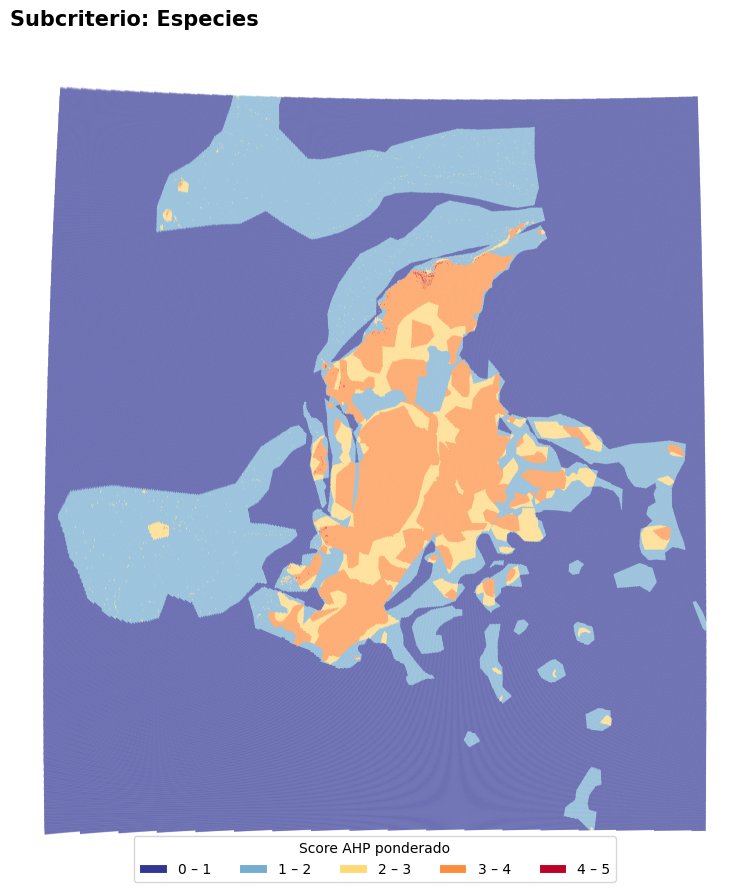

In [139]:
plot_subcriterio_map(
    total_sub,
    column="Especies",
    title="Subcriterio: Especies",
)

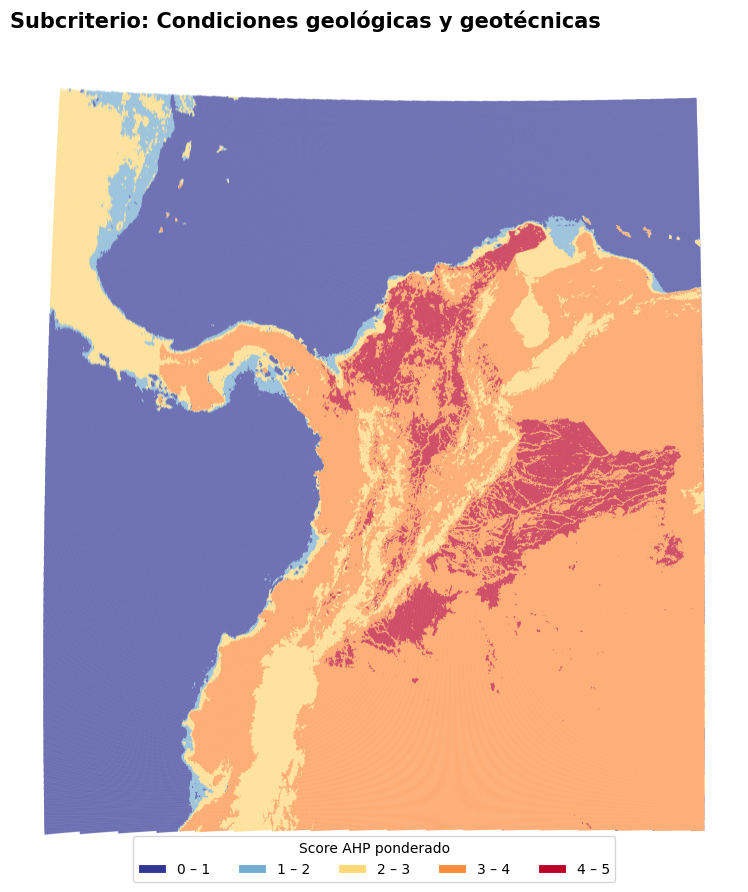

In [140]:
plot_subcriterio_map(
    total_sub,
    column="Condiciones",
    title="Subcriterio: Condiciones geológicas y geotécnicas",
)

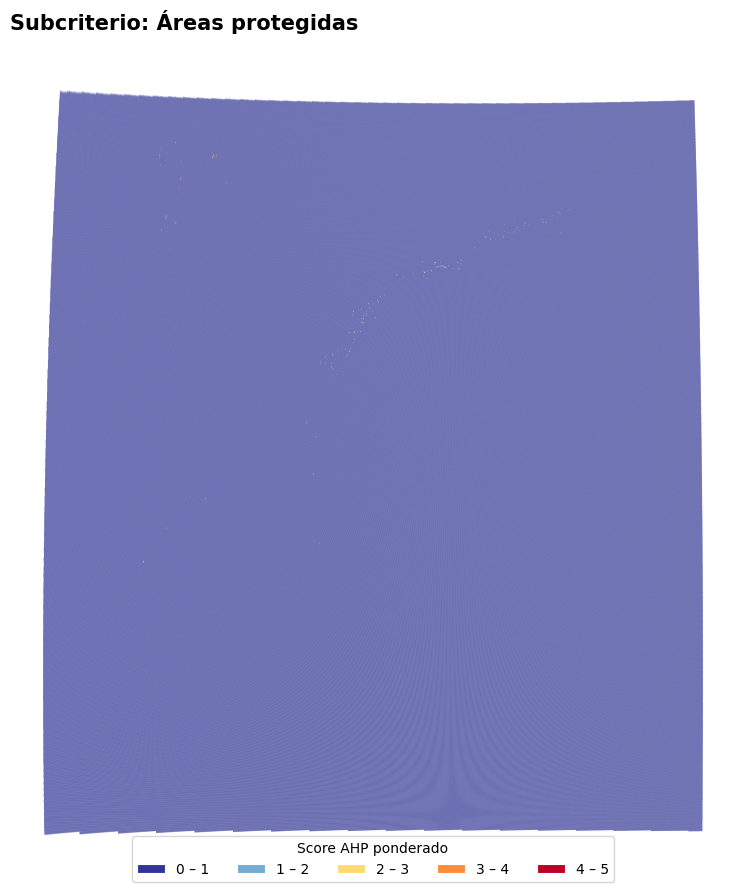

In [141]:
plot_subcriterio_map(
    total_sub,
    column="Areas",
    title="Subcriterio: Áreas protegidas",
)

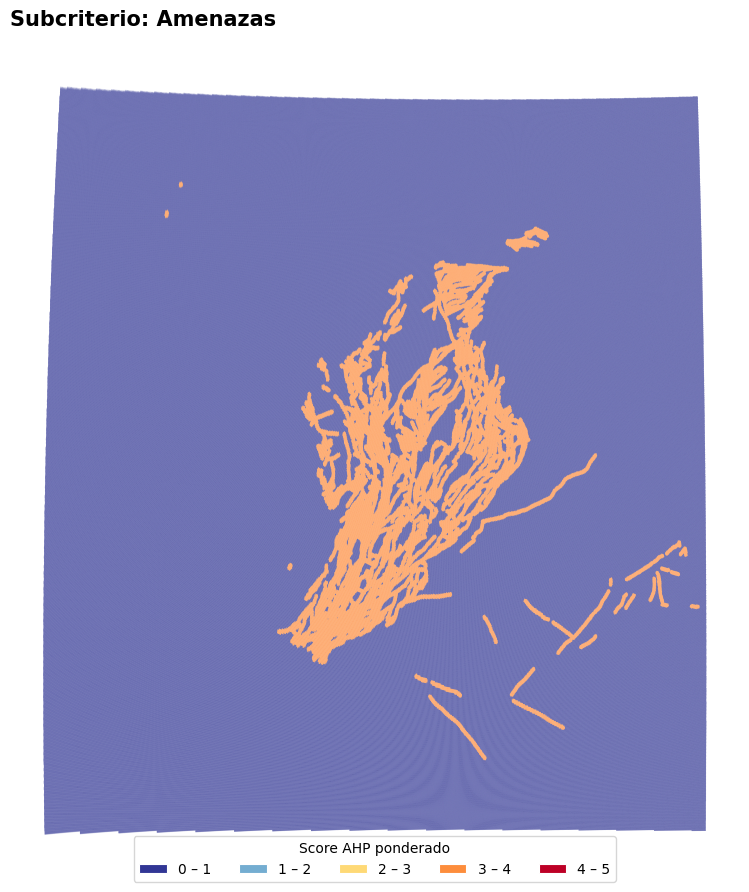

In [142]:
plot_subcriterio_map(
    total_sub,
    column="Amenazas",
    title="Subcriterio: Amenazas",
)